# `modeling.ipynb` — Forecasting Anomalías T2M · ERA5 Caribe (1976–2025)

**Autores:** Mateo Gómez · Miguel Jaimes · David Ibáñez — Universidad del Norte, 2026

**Pre-requisito:** ejecutar `preprocessing.ipynb` para generar `outputs_preprocessing/`.

### Diseño metodológico

| Familia | Modelos | Input |
|---------|---------|-------|
| **Baselines** | Persistence, Climatología | — |
| **Tabular** | Ridge, Lasso, XGBoost, MLP | Features de lags (X_train/val/test) |
| **Secuencial DL** | LSTM, BiLSTM, CNN-LSTM, TCN | Secuencias sobre concat(train+val+test), evaluadas por splits de target |

Las dos familias (Tabular y DL) usan **representaciones distintas** del mismo dataset:
- Tabular: features de lags pre-computadas en preprocessing.
- DL: secuencias construidas aquí sobre la serie completa normalizada, con split por índice de target.

La comparación entre familias es válida y metodológicamente correcta, documentada en la tabla de resultados.

> **Solo datos reales ERA5. Evaluación final en test holdout no visto.**


## Carga de datos

In [1]:
import os, json, pickle, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats as sp_stats

from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import warnings
warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# XGBoost — siempre CPU para portabilidad
XGB_TREE = "hist"
XGB_DEV  = "cpu"

PREP_DIR   = Path("outputs_preprocessing")
MODELS_DIR = Path("outputs_models")
MODELS_DIR.mkdir(exist_ok=True)
PLOT_DIR   = Path("outputs_plots")
PLOT_DIR.mkdir(exist_ok=True)

assert PREP_DIR.exists(), f"Ejecutar preprocessing.ipynb primero. No se encontró {PREP_DIR}"
print(f" {PREP_DIR} encontrado")
print(f"  TF: {tf.__version__}  |  XGBoost: {xgb.__version__}  |  CPU-only XGB: {XGB_TREE}")


 outputs_preprocessing encontrado
  TF: 2.10.0  |  XGBoost: 2.1.4  |  CPU-only XGB: hist


In [2]:
# ── Carga de artefactos ───────────────────────────────────────────────────────
seqs = np.load(PREP_DIR / "sequences.npz", allow_pickle=True)
X_train, y_train = seqs["X_train"], seqs["y_train"]
X_val,   y_val   = seqs["X_val"],   seqs["y_val"]
X_test,  y_test  = seqs["X_test"],  seqs["y_test"]
y_train_diff = seqs["y_train_diff"]
y_val_diff   = seqs["y_val_diff"]
y_test_diff  = seqs["y_test_diff"]
y_train_raw = seqs["y_train_raw"]
y_val_raw   = seqs["y_val_raw"]
y_test_raw  = seqs["y_test_raw"]
y_train_diff_raw = seqs["y_train_diff_raw"]
y_val_diff_raw   = seqs["y_val_diff_raw"]
y_test_diff_raw  = seqs["y_test_diff_raw"]
# Cargar y_base para reconstrucción
y_train_base_raw = seqs["y_train_base_raw"]
y_val_base_raw   = seqs["y_val_base_raw"]
y_test_base_raw  = seqs["y_test_base_raw"]
# Fechas del target (input_date + horizon)
td_train = pd.to_datetime(seqs["target_dates_train"])
td_val   = pd.to_datetime(seqs["target_dates_val"])
td_test  = pd.to_datetime(seqs["target_dates_test"])

with open(PREP_DIR / "scaler_X.pkl", "rb") as f: scaler_X = pickle.load(f)
with open(PREP_DIR / "scaler_y.pkl", "rb") as f: scaler_y = pickle.load(f)
with open(PREP_DIR / "cv_splits.pkl","rb") as f: cv_splits = pickle.load(f)
with open(PREP_DIR / "pipeline_metadata.json") as f: META = json.load(f)
with open(PREP_DIR / "scaler_y_diff.pkl", "rb") as f: scaler_y_diff = pickle.load(f)
HORIZON      = META["horizon"]
FEATURE_COLS = META["feature_cols"]
N_FEATURES   = META["n_features"]
TARGET       = META["target"]

# Validaciones
for name, X, y in [("train",X_train,y_train),("val",X_val,y_val),("test",X_test,y_test)]:
    assert len(X)==len(y) and not np.isnan(X).any() and not np.isnan(y).any(), f"Error en {name}"
for i,(tr,va) in enumerate(cv_splits):
    assert tr.max() < len(X_train) and va.max() < len(X_train)

print(f" Artefactos cargados")
print(f"  HORIZON    : {HORIZON}m")
print(f"  N_FEATURES : {N_FEATURES}")
print(f"  X_train    : {X_train.shape}  target: {td_train[0].date()} → {td_train[-1].date()}")
print(f"  X_val      : {X_val.shape}    target: {td_val[0].date()}   → {td_val[-1].date()}")
print(f"  X_test     : {X_test.shape}   target: {td_test[0].date()}  → {td_test[-1].date()}")
print(f"  Block CV   : {len(cv_splits)} folds")


 Artefactos cargados
  HORIZON    : 3m
  N_FEATURES : 44
  X_train    : (465, 44)  target: 1977-04-01 → 2015-12-01
  X_val      : (60, 44)    target: 2016-01-01   → 2020-12-01
  X_test     : (60, 44)   target: 2021-01-01  → 2025-12-01
  Block CV   : 5 folds


## Funciones

In [3]:
# ── Métricas ─────────────────────────────────────────────────────────────────
def descalar(y_sc):
    return scaler_y.inverse_transform(np.array(y_sc).reshape(-1,1)).ravel()

def compute_metrics(y_true_sc, y_pred_sc, label=""):
    """Métricas en escala real (K). ACC > 0.6 → skill climático operacional."""
    yt = descalar(y_true_sc); yp = descalar(y_pred_sc)
    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    mae  = float(mean_absolute_error(yt, yp))
    r2   = float(r2_score(yt, yp))
    a    = yt - yt.mean(); b = yp - yp.mean()
    acc  = float(np.sum(a*b) / (np.sqrt(np.sum(a**2)*np.sum(b**2)) + 1e-10))
    if label:
        print(f"  {label:<28}  RMSE={rmse:.4f}K  MAE={mae:.4f}K  R²={r2:.4f}  ACC={acc:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2, "acc": acc}
def compute_metrics_real(y_true_K, y_pred_K, label=""):
    """Métricas cuando ambos arrays ya están en K (no descala internamente).
    Usar exclusivamente para modelos DL tras reconstrucción base + diff."""
    rmse = float(np.sqrt(mean_squared_error(y_true_K, y_pred_K)))
    mae  = float(mean_absolute_error(y_true_K, y_pred_K))
    r2   = float(r2_score(y_true_K, y_pred_K))
    a    = y_true_K - y_true_K.mean()
    b    = y_pred_K - y_pred_K.mean()
    acc  = float(np.sum(a*b) / (np.sqrt(np.sum(a**2)*np.sum(b**2)) + 1e-10))
    if label:
        print(f"  {label:<28}  RMSE={rmse:.4f}K  MAE={mae:.4f}K  R²={r2:.4f}  ACC={acc:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2, "acc": acc}
def cv_score_sklearn(model_fn, X, y, splits):
    fold_rmse = []
    for fold, (tr, va) in enumerate(splits):
        m = model_fn(); m.fit(X[tr], y[tr])
        r = compute_metrics(y[va], m.predict(X[va]))["rmse"]
        fold_rmse.append(r); print(f"    Fold {fold+1}  CV-RMSE={r:.4f}K")
    mean_r = float(np.mean(fold_rmse))
    print(f"    CV-RMSE medio          {mean_r:.4f}K")
    return mean_r

def get_callbacks(monitor="val_loss", patience=20):
    return [
        callbacks.EarlyStopping(monitor=monitor, patience=patience,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor=monitor, factor=0.5,
                                    patience=patience//2, min_lr=1e-6, verbose=0),
    ]

results = {}
print(" Funciones de métricas y utilidades definidas")


 Funciones de métricas y utilidades definidas


## Modelos baselines

In [4]:
# ── Baselines ─────────────────────────────────────────────────────────────────
# Persistence correcta: ŷ(t+h) = y(t) → usar el último valor de train/val como seed
# En escala normalizada: y_persist_val[i] = y en la posición i - h (si i >= h),
# o la última observación de train disponible (para i < h).
h = HORIZON

y_persist_val  = np.concatenate([y_train[-h:], y_val[:-h]])[:len(y_val)]
y_persist_test = np.concatenate([y_val[-h:],   y_test[:-h]])[:len(y_test)]

print("── Persistence (ŷ(t+h) = y(t)) ──")
pers_val  = compute_metrics(y_val,  y_persist_val,  "Persistence Val")
pers_test = compute_metrics(y_test, y_persist_test, "Persistence Test")
results["Persistence"] = {"cv_rmse": pers_val["rmse"], "val": pers_val, "test": pers_test}

print("\n── Climatología (anomalía=0) ──")
def zero_scaled(n):
    return scaler_y.transform(np.zeros((n,1))).ravel()
clim_val  = compute_metrics(y_val,  zero_scaled(len(y_val)),  "Climatología Val")
clim_test = compute_metrics(y_test, zero_scaled(len(y_test)), "Climatología Test")
results["Climatología"] = {"cv_rmse": clim_val["rmse"], "val": clim_val, "test": clim_test}

print(f"\n  Referencia Persistence Val-RMSE = {pers_val['rmse']:.4f}K")


── Persistence (ŷ(t+h) = y(t)) ──
  Persistence Val               RMSE=0.3134K  MAE=0.2491K  R²=-0.1590  ACC=0.4499
  Persistence Test              RMSE=0.3746K  MAE=0.2936K  R²=0.4649  ACC=0.7357

── Climatología (anomalía=0) ──
  Climatología Val              RMSE=0.7453K  MAE=0.6861K  R²=-5.5542  ACC=0.0000
  Climatología Test             RMSE=0.9622K  MAE=0.8161K  R²=-2.5301  ACC=0.0000

  Referencia Persistence Val-RMSE = 0.3134K


podemos observar los ACC y el RMSE que los modelos en el futuro deberan superar 

## Modelos tabulares

In [5]:
# ── Ridge ──────────────────────────────────────────────────────────────────────
print("── Ridge ──")
ridge_cv    = cv_score_sklearn(lambda: Ridge(alpha=10.0), X_train, y_train, cv_splits)
ridge_final = Ridge(alpha=10.0); ridge_final.fit(X_train, y_train)
ridge_val   = compute_metrics(y_val, ridge_final.predict(X_val), "Ridge Val")
results["Ridge"] = {"cv_rmse": ridge_cv, "val": ridge_val, "model": ridge_final}

print("\n── Lasso ──")
lasso_cv    = cv_score_sklearn(
    lambda: Lasso(alpha=0.1, max_iter=5000, random_state=SEED), X_train, y_train, cv_splits)
lasso_final = Lasso(alpha=0.1, max_iter=5000, random_state=SEED); lasso_final.fit(X_train, y_train)
lasso_val   = compute_metrics(y_val, lasso_final.predict(X_val), "Lasso Val")
n_nonzero   = (np.abs(lasso_final.coef_) > 1e-6).sum()
print(f"  Lasso features seleccionadas: {n_nonzero}/{len(lasso_final.coef_)}")
results["Lasso"] = {"cv_rmse": lasso_cv, "val": lasso_val, "model": lasso_final}


── Ridge ──
    Fold 1  CV-RMSE=0.4268K
    Fold 2  CV-RMSE=0.2537K
    Fold 3  CV-RMSE=0.3123K
    Fold 4  CV-RMSE=0.2233K
    Fold 5  CV-RMSE=0.5631K
    CV-RMSE medio          0.3558K
  Ridge Val                     RMSE=0.2348K  MAE=0.1882K  R²=0.3494  ACC=0.6750

── Lasso ──
    Fold 1  CV-RMSE=0.4281K
    Fold 2  CV-RMSE=0.2197K
    Fold 3  CV-RMSE=0.2870K
    Fold 4  CV-RMSE=0.2638K
    Fold 5  CV-RMSE=0.5853K
    CV-RMSE medio          0.3568K
  Lasso Val                     RMSE=0.2757K  MAE=0.2339K  R²=0.1031  ACC=0.6193
  Lasso features seleccionadas: 4/44


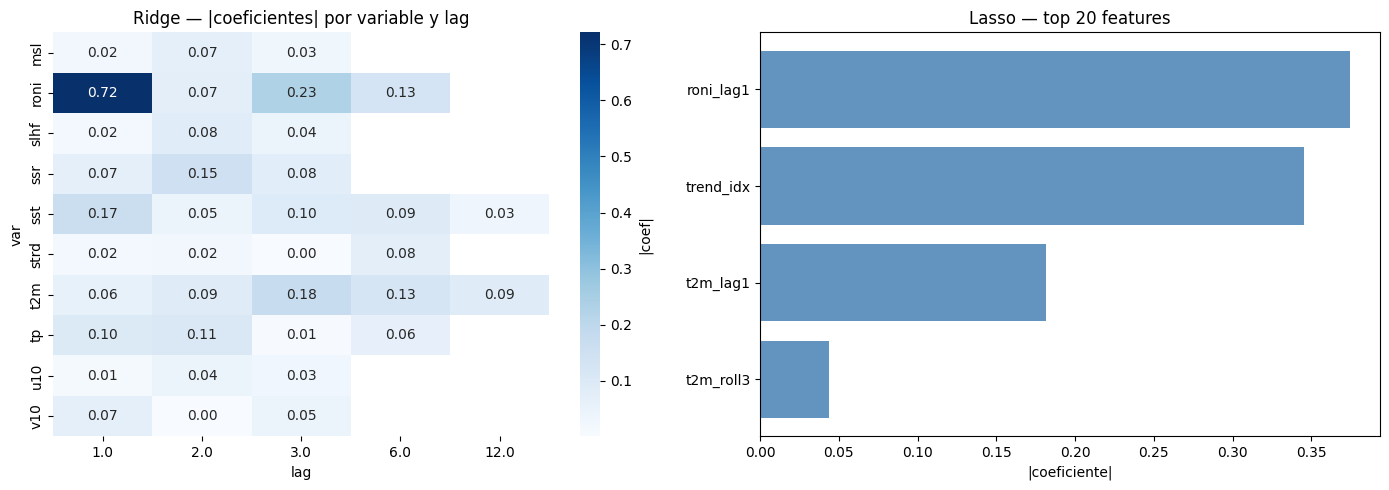

In [6]:
# ── Heatmap coeficientes Ridge y top-features Lasso ──────────────────────────
coefs = np.abs(ridge_final.coef_)
if len(coefs) == len(FEATURE_COLS):
    df_c = pd.DataFrame({"feature": FEATURE_COLS, "coef": coefs})
    df_c["var"] = df_c["feature"].str.extract(r"^([a-z0-9]+)_")
    df_c["lag"] = pd.to_numeric(df_c["feature"].str.extract(r"lag(\d+)")[0], errors="coerce")
    pivot = df_c.dropna(subset=["lag"]).pivot_table(
        index="var", columns="lag", values="coef", aggfunc="mean")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if not pivot.empty:
        sns.heatmap(pivot, ax=axes[0], cmap="Blues", annot=True, fmt=".2f",
                    cbar_kws={"label": "|coef|"})
        axes[0].set_title("Ridge — |coeficientes| por variable y lag")
    df_lasso_nz = df_c[np.abs(lasso_final.coef_) > 1e-6].copy()
    df_lasso_nz["coef_abs"] = np.abs(lasso_final.coef_[np.abs(lasso_final.coef_) > 1e-6])
    df_lasso_nz = df_lasso_nz.sort_values("coef_abs").tail(20)
    axes[1].barh(df_lasso_nz["feature"], df_lasso_nz["coef_abs"], color="steelblue", alpha=0.85)
    axes[1].set_title("Lasso — top 20 features"); axes[1].set_xlabel("|coeficiente|")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "fig_coeficientes_lineales.png", dpi=150, bbox_inches="tight")
    plt.show()


**Benchmarks lineales: Ridge vs Lasso**

La figura presenta los resultados del entrenamiento de los modelos de referencia lineales **Ridge** y **Lasso**, utilizados como punto de comparación dentro del pipeline del proyecto.

**Ridge — Distribución de coeficientes por variable y rezago**

El mapa de calor muestra la magnitud absoluta de los coeficientes asignados por Ridge a cada variable en distintos *lags*. Se observa que:

* **`roni_lag1` domina claramente**, con el mayor peso (~0.72), lo que indica una fuerte dependencia temporal inmediata del sistema.
* Variables como **`t2m`**, **`tp`** y **`sst`** presentan contribuciones moderadas distribuidas en varios rezagos, sugiriendo efectos más difusos en el tiempo.
* Ridge **no elimina variables**, sino que distribuye el peso entre múltiples features, capturando señales débiles pero potencialmente relevantes.
* La influencia decrece generalmente a medida que aumenta el lag, lo cual es consistente con la pérdida de memoria temporal.

**Lasso — Selección de variables más relevantes**

El gráfico de barras muestra las variables más importantes según Lasso:

* **`roni_lag1` y `trend_idx` concentran la mayor importancia**, indicando que el modelo favorece señales fuertes y directas.
* **`t2m_lag1`** también aparece como predictor relevante, aunque con menor peso.
* Variables como **`t2m_roll3`** tienen contribuciones marginales.
* A diferencia de Ridge, Lasso realiza **selección automática de variables**, eliminando aquellas con menor relevancia (coeficiente = 0).

**Comparación e implicaciones**

* **Ridge**: útil para capturar relaciones distribuidas y evitar perder información, aunque con menor interpretabilidad.
* **Lasso**: favorece modelos más simples y explicables, identificando las variables clave del sistema.
* Ambos modelos coinciden en la importancia crítica de **`roni_lag1`**, validando su rol como principal predictor en el problema.

En conjunto, estos benchmarks proporcionan una base sólida para evaluar modelos más complejos (como CNN-LSTM o ensembles), y ayudan a entender la estructura subyacente de las variables predictoras.


In [7]:
# ── XGBoost (CPU, tree_method=hist) ──────────────────────────────────────────
print("── XGBoost (tree_method=hist, device=cpu) ──")

# Parámetros optimizados para dataset pequeño
xgb_params = dict(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.6,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=2.0,
    early_stopping_rounds=30,
    tree_method="hist",
    device="cpu",
    random_state=SEED,
)

# Cross-validation
fold_rmse, best_iters = [], []

for fold, (tr, va) in enumerate(cv_splits):
    m = xgb.XGBRegressor(**xgb_params)

    m.fit(
        X_train[tr], y_train[tr],
        eval_set=[(X_train[va], y_train[va])],
        verbose=False
    )

    preds = m.predict(X_train[va])
    r = compute_metrics(y_train[va], preds)["rmse"]

    fold_rmse.append(r)
    best_iters.append(m.best_iteration)

    print(f"    Fold {fold+1}  CV-RMSE={r:.4f}K  best_iter={m.best_iteration}")

xgb_cv = float(np.mean(fold_rmse))
print(f"    CV-RMSE medio          {xgb_cv:.4f}K")

# Modelo final (con early stopping usando validation set)
xgb_final = xgb.XGBRegressor(**xgb_params)

xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_val = compute_metrics(y_val, xgb_final.predict(X_val), "XGBoost Val")

results["XGBoost"] = {
    "cv_rmse": xgb_cv,
    "val": xgb_val,
    "model": xgb_final
}

── XGBoost (tree_method=hist, device=cpu) ──
    Fold 1  CV-RMSE=0.4141K  best_iter=68
    Fold 2  CV-RMSE=0.2055K  best_iter=3
    Fold 3  CV-RMSE=0.3253K  best_iter=70
    Fold 4  CV-RMSE=0.1989K  best_iter=92
    Fold 5  CV-RMSE=0.5157K  best_iter=11
    CV-RMSE medio          0.3319K
  XGBoost Val                   RMSE=0.2607K  MAE=0.2018K  R²=0.1982  ACC=0.5201


In [8]:
# ── MLP (tabular) ─────────────────────────────────────────────────────────────
def build_mlp():
    inp = keras.Input(shape=(N_FEATURES,))
    x = layers.Dense(64, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1)(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return m

print("── MLP ──")
fold_rmse = []
for fold, (tr, va) in enumerate(cv_splits):
    print(f"    Fold {fold+1}...", end=" ", flush=True)
    m = build_mlp()
    m.fit(X_train[tr], y_train[tr], validation_data=(X_train[va], y_train[va]),
          epochs=200, batch_size=32, verbose=0, callbacks=get_callbacks())
    r = compute_metrics(y_train[va], m.predict(X_train[va], verbose=0).flatten())["rmse"]
    fold_rmse.append(r); print(f"CV-RMSE={r:.4f}K")
    keras.backend.clear_session()
mlp_cv = float(np.mean(fold_rmse))
print(f"    CV-RMSE medio          {mlp_cv:.4f}K")
mlp_final = build_mlp()
mlp_final.fit(X_train, y_train, epochs=300, batch_size=32, verbose=0,
              callbacks=get_callbacks("loss", 30))
mlp_val = compute_metrics(y_val, mlp_final.predict(X_val, verbose=0).flatten(), "MLP Val")
results["MLP"] = {"cv_rmse": mlp_cv, "val": mlp_val, "model": mlp_final}

── MLP ──
    Fold 1... CV-RMSE=0.4148K
    Fold 2... CV-RMSE=0.2723K
    Fold 3... CV-RMSE=0.3321K
    Fold 4... CV-RMSE=0.2726K
    Fold 5... WARNING:tensorflow:5 out of the last 13 calls to <function Model.make_predict_function.<locals>.predict_function at 0x0000026B734733A0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
CV-RMSE=0.4577K
    CV-RMSE medio          0.3499K
  MLP Val                       RMSE=0.2624K  MAE=0.2064K  R²=0.1878  ACC=0.6109


## Modelos de deep learning

In [9]:
# ── Construcción de secuencias DL ─────────────────────────────────────────────
# CORRECCIÓN: las secuencias se construyen sobre TODA la serie (train+val+test)
# para que las secuencias de test tengan contexto de meses anteriores.
# El split se hace por índice del TARGET (tidx), no por índice de input.
N_LAGS   = 24
INPUT_SEQ = (N_LAGS, N_FEATURES)

X_full = np.concatenate([X_train, X_val, X_test], axis=0)
y_full_diff = np.concatenate([y_train_diff, y_val_diff, y_test_diff], axis=0)
y_full_raw  = np.concatenate([y_train_raw,      y_val_raw,      y_test_raw],      axis=0)
y_full_base = np.concatenate([y_train_base_raw, y_val_base_raw, y_test_base_raw], axis=0)

n_tr_full = len(X_train)
n_va_full = len(X_train) + len(X_val)

def build_sequences(Xf, yf, n_lags, horizon):
    Xo, yo, tidx = [], [], []
    for i in range(len(Xf) - n_lags - horizon + 1):
        Xo.append(Xf[i:i+n_lags])
        yo.append(yf[i+n_lags+horizon-1])
        tidx.append(i+n_lags+horizon-1)  
    return (np.array(Xo, dtype=np.float32),
            np.array(yo, dtype=np.float32),
            np.array(tidx))

X_seq, y_seq_diff, tidx = build_sequences(X_full, y_full_diff, N_LAGS, HORIZON)

# Split por índice del TARGET en X_full
mask_tr = tidx < n_tr_full
mask_va = (tidx >= n_tr_full) & (tidx < n_va_full)
mask_te = tidx >= n_va_full

X_tr_seq, y_tr_seq_diff = X_seq[mask_tr], y_seq_diff[mask_tr]
X_va_seq, y_va_seq_diff = X_seq[mask_va], y_seq_diff[mask_va]
X_te_seq, y_te_seq_diff = X_seq[mask_te], y_seq_diff[mask_te]
# Block CV secuencial sobre X_tr_seq
def make_seq_cv(n, n_splits=5, gap=12):
    block = (n - gap*n_splits) // (n_splits+1)
    splits = []
    for i in range(n_splits):
        te = block*(i+1); vs = te+gap; ve = min(vs+block, n)
        if ve > vs: splits.append((np.arange(0, te), np.arange(vs, ve)))
    return splits, block

cv_seq, block_seq = make_seq_cv(len(X_tr_seq))

print(f"Secuencias DL (input_context sobre train+val+test, target split por índice):")
print(f"  X_tr_seq : {X_tr_seq.shape}  (target en train)")
print(f"  X_va_seq : {X_va_seq.shape}  (target en val)")
print(f"  X_te_seq : {X_te_seq.shape}  (target en test, con contexto completo)")
print(f"  Block CV secuencial: {len(cv_seq)} folds | gap=12 | block≈{block_seq}")
print(f"  Input LSTM: {INPUT_SEQ}")


Secuencias DL (input_context sobre train+val+test, target split por índice):
  X_tr_seq : (439, 24, 44)  (target en train)
  X_va_seq : (60, 24, 44)  (target en val)
  X_te_seq : (60, 24, 44)  (target en test, con contexto completo)
  Block CV secuencial: 5 folds | gap=12 | block≈63
  Input LSTM: (24, 44)


In [10]:
def dl_cv_seq(build_fn, epochs=200, patience=10):
    fold_rmse, fold_hist = [], []
    for fold, (tr, va) in enumerate(cv_seq):
        print(f"    Fold {fold+1}...", end=" ", flush=True)
        m = build_fn()
        h = m.fit(X_tr_seq[tr], y_tr_seq_diff[tr],
                  validation_data=(X_tr_seq[va], y_tr_seq_diff[va]),
                  epochs=epochs, batch_size=32, verbose=0,
                  callbacks=get_callbacks(patience=patience))
        r = compute_metrics(y_tr_seq_diff[va],
                            m.predict(X_tr_seq[va], verbose=0).flatten())["rmse"]
        fold_rmse.append(r); fold_hist.append(h.history)
        print(f"CV-RMSE={r:.4f}K  ep={len(h.history['loss'])}")
        keras.backend.clear_session()
    mean_r = float(np.mean(fold_rmse))
    print(f"    CV-RMSE medio          {mean_r:.4f}K")
    return mean_r, fold_hist
def train_final_seq(build_fn, epochs=200, patience=15):
    m = build_fn()
    m.fit(X_tr_seq, y_tr_seq_diff, epochs=epochs, batch_size=32, verbose=0,
          callbacks=get_callbacks("loss", patience))
    return m


In [11]:
def build_lstm():
    inp = keras.Input(shape=INPUT_SEQ)
    x = layers.LSTM(
        16,
        return_sequences=False,
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )(inp)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(
        16,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1)(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(5e-4), loss="mse")
    return m

print("── LSTM ──")
lstm_cv, lstm_hist = dl_cv_seq(build_lstm)
lstm_f   = train_final_seq(build_lstm)
# predicción diferencial sobre VAL
y_pred_diff = lstm_f.predict(X_va_seq, verbose=0).flatten()

# desescalar
y_pred_diff = scaler_y_diff.inverse_transform(
                  y_pred_diff.reshape(-1,1)).ravel()

# base: t2m(t) — valor en el momento de predicción, NO el target
y_base = y_full_base[tidx[mask_va]]

# reconstrucción
y_pred = y_base + y_pred_diff

# target real: t2m(t+3)
y_true = y_full_raw[tidx[mask_va]]     # ← tidx[mask_va], no tidx][mask_va]

lstm_val = compute_metrics_real(y_true, y_pred, "LSTM Val")
results["LSTM"] = {"cv_rmse": lstm_cv, "val": lstm_val,
                   "model": lstm_f, "hist_cv": lstm_hist}


── LSTM ──
    Fold 1... CV-RMSE=0.3679K  ep=41
    Fold 2... CV-RMSE=0.3817K  ep=16
    Fold 3... CV-RMSE=0.3731K  ep=43
    Fold 4... CV-RMSE=0.3326K  ep=16
    Fold 5... CV-RMSE=0.4636K  ep=41
    CV-RMSE medio          0.3838K
  LSTM Val                      RMSE=0.3090K  MAE=0.2466K  R²=-0.1264  ACC=0.4061


In [12]:
# ── BiLSTM ────────────────────────────────────────────────────────────────────
# NOTA METODOLÓGICA: BiLSTM aprende dependencias bidireccionales DENTRO de la
# ventana de entrada (N_LAGS meses históricos). No accede a datos futuros
# respecto al target (que está FUERA de la ventana). Sin leakage temporal.
def build_bilstm():
    inp = keras.Input(shape=INPUT_SEQ)
    x = layers.Bidirectional(
        layers.LSTM(16, return_sequences=False,
                    kernel_regularizer=keras.regularizers.l2(1e-4))
    )(inp)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(16, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1)(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(5e-4), loss="mse")
    return m

print("── BiLSTM ──")
bilstm_cv, bilstm_hist = dl_cv_seq(build_bilstm)
bilstm_f   = train_final_seq(build_bilstm)

# predicción diferencial sobre VAL
y_pred_diff = bilstm_f.predict(X_va_seq, verbose=0).flatten()

# desescalar
y_pred_diff = scaler_y_diff.inverse_transform(
                  y_pred_diff.reshape(-1,1)).ravel()

# base: t2m(t) — valor en el momento de predicción, NO el target
y_base = y_full_base[tidx[mask_va]]

# reconstrucción
y_pred = y_base + y_pred_diff

# target real: t2m(t+3)
y_true = y_full_raw[tidx[mask_va]]     # ← tidx[mask_va], no tidx][mask_va]
bilstm_val = compute_metrics_real(y_true, y_pred, "BiLSTM Val")

results["BiLSTM"] = {
    "cv_rmse": bilstm_cv,
    "val": bilstm_val,
    "model": bilstm_f,
    "hist_cv": bilstm_hist
}


── BiLSTM ──
    Fold 1... CV-RMSE=0.4051K  ep=44
    Fold 2... CV-RMSE=0.3774K  ep=17
    Fold 3... CV-RMSE=0.3853K  ep=56
    Fold 4... CV-RMSE=0.3132K  ep=25
    Fold 5... CV-RMSE=0.4400K  ep=31
    CV-RMSE medio          0.3842K
  BiLSTM Val                    RMSE=0.2975K  MAE=0.2460K  R²=-0.0445  ACC=0.4770


In [13]:
# ── CNN-LSTM ──────────────────────────────────────────────────────────────────
def build_cnn_lstm():
    inp = keras.Input(shape=INPUT_SEQ)
    x = layers.Conv1D(
        16, 3, padding="causal", activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv1D(
        16, 3, padding="causal", activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(16,
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(16, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1)(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(5e-4), loss="mse")
    return m
print("── CNN-LSTM ──")
cnnlstm_cv, cnnlstm_hist = dl_cv_seq(build_cnn_lstm)
cnnlstm_f   = train_final_seq(build_cnn_lstm)
# predicción diferencial sobre VAL
y_pred_diff = cnnlstm_f.predict(X_va_seq, verbose=0).flatten()

# desescalar
y_pred_diff = scaler_y_diff.inverse_transform(
                  y_pred_diff.reshape(-1,1)).ravel()

# base: t2m(t) — valor en el momento de predicción, NO el target
y_base = y_full_base[tidx[mask_va]]

# reconstrucción
y_pred = y_base + y_pred_diff

# target real: t2m(t+3)
y_true = y_full_raw[tidx[mask_va]]     # ← tidx[mask_va], no tidx][mask_va]
cnnlstm_val = compute_metrics_real(y_true, y_pred, "CNN-LSTM Val")
results["CNN-LSTM"] = {
    "cv_rmse": cnnlstm_cv,
    "val": cnnlstm_val,
    "model": cnnlstm_f,
    "hist_cv": cnnlstm_hist
}


── CNN-LSTM ──
    Fold 1... CV-RMSE=0.3809K  ep=41
    Fold 2... CV-RMSE=0.3868K  ep=43
    Fold 3... CV-RMSE=0.3622K  ep=78
    Fold 4... CV-RMSE=0.3132K  ep=24
    Fold 5... CV-RMSE=0.4521K  ep=27
    CV-RMSE medio          0.3790K
  CNN-LSTM Val                  RMSE=0.3007K  MAE=0.2441K  R²=-0.0667  ACC=0.4583


In [14]:
# ── TCN (ADAPTADO A Δy Y DATASET PEQUEÑO) ───────────────────────────────
def build_tcn(filters=16, kernel_size=3, n_blocks=3):
    inp = keras.Input(shape=INPUT_SEQ)
    x = inp
    for i in range(n_blocks):
        d = 2**i
        res = x
        x = layers.Conv1D(
            filters, kernel_size,
            padding="causal",
            dilation_rate=d,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(1e-4)
        )(x)
        x = layers.Dropout(0.4)(x)
        x = layers.Conv1D(
            filters, kernel_size,
            padding="causal",
            dilation_rate=d,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(1e-4)
        )(x)
        x = layers.Dropout(0.4)(x)
        if res.shape[-1] != filters:
            res = layers.Conv1D(filters, 1)(res)
        x = layers.Add()([x, res])
        x = layers.LayerNormalization()(x)

    x = layers.Lambda(lambda t: t[:, -1, :])(x)
    x = layers.Dense(16, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1)(x)

    m = keras.Model(inp, out)
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
        loss="mse"
    )
    return m
print("── TCN ──")
tcn_cv, tcn_hist = dl_cv_seq(build_tcn, epochs=250, patience=20)
tcn_f   = train_final_seq(build_tcn, epochs=300, patience=30)

# predicción diferencial sobre VAL
y_pred_diff = tcn_f.predict(X_va_seq, verbose=0).flatten()
# desescalar
y_pred_diff = scaler_y_diff.inverse_transform(
                  y_pred_diff.reshape(-1,1)).ravel()

y_base = y_full_base[tidx[mask_va]]

# reconstrucción
y_pred = y_base + y_pred_diff

# target real: t2m(t+3)
y_true = y_full_raw[tidx[mask_va]]     

tcn_val = compute_metrics_real(y_true, y_pred, "TCN Val")
results["TCN"] = {"cv_rmse": tcn_cv, "val": tcn_val, "model": tcn_f, "hist_cv": tcn_hist}

── TCN ──
    Fold 1... CV-RMSE=0.3569K  ep=128
    Fold 2... CV-RMSE=0.4140K  ep=69
    Fold 3... CV-RMSE=0.3611K  ep=40
    Fold 4... CV-RMSE=0.3157K  ep=30
    Fold 5... CV-RMSE=0.4463K  ep=42
    CV-RMSE medio          0.3788K
  TCN Val                       RMSE=0.2964K  MAE=0.2438K  R²=-0.0369  ACC=0.4685


## Evaluacion inicial y seleccion de mejor modelo benchmark

In [15]:
# ── Selección por CV (test NO interviene) ─────────────────────────────────────
rows = []
for name, s in results.items():
    rows.append({
        "Modelo"       : name,
        "Familia"      : "Baseline" if name in ["Persistence","Climatología"]
                         else "Tabular" if name in ["Ridge","Lasso","XGBoost","MLP"]
                         else "DL-Secuencial",
        "CV-RMSE (K)"  : round(s.get("cv_rmse", float("nan")), 4),
        "Val-RMSE (K)" : round(s["val"]["rmse"], 4) if "val" in s else float("nan"),
        "Val-ACC"      : round(s["val"]["acc"],  4) if "val" in s else float("nan"),
    })
df_sel = pd.DataFrame(rows).sort_values("CV-RMSE (K)").reset_index(drop=True)

print("\n" + "="*65)
print("  SELECCIÓN — basada en CV-RMSE (test NO interviene en ningún caso)")
print("="*65)
print(df_sel.to_string(index=False))
print("="*65)
best_cv_name = df_sel.iloc[0]["Modelo"]
print(f"\n  Mejor modelo por CV-RMSE: {best_cv_name}")



  SELECCIÓN — basada en CV-RMSE (test NO interviene en ningún caso)
      Modelo       Familia  CV-RMSE (K)  Val-RMSE (K)  Val-ACC
 Persistence      Baseline       0.3134        0.3134   0.4499
     XGBoost       Tabular       0.3319        0.2607   0.5201
         MLP       Tabular       0.3499        0.2624   0.6109
       Ridge       Tabular       0.3558        0.2348   0.6750
       Lasso       Tabular       0.3568        0.2757   0.6193
         TCN DL-Secuencial       0.3788        0.2964   0.4685
    CNN-LSTM DL-Secuencial       0.3790        0.3007   0.4583
        LSTM DL-Secuencial       0.3838        0.3090   0.4061
      BiLSTM DL-Secuencial       0.3842        0.2975   0.4770
Climatología      Baseline       0.7453        0.7453   0.0000

  Mejor modelo por CV-RMSE: Persistence


In [16]:
# ── Evaluación final en TEST — ejecución única ────────────────────────────────
print("=" * 65)
print("  EVALUACIÓN FINAL EN TEST — EJECUCIÓN ÚNICA")
print("=" * 65)

test_res = {}

# =========================================================
# 1. MODELOS TABULARES (predicen nivel directamente)
# =========================================================
for name in ["Persistence","Climatología","Ridge","Lasso","XGBoost","MLP"]:
    if name not in results:
        continue

    if name == "Persistence":
        yp, yt = y_persist_test, y_test_raw

    elif name == "Climatología":
        yp = np.full_like(y_test_raw, y_train_raw.mean())
        yt = y_test_raw

    else:
        yp = results[name]["model"].predict(X_test).flatten()
        yp = scaler_y.inverse_transform(yp.reshape(-1,1)).ravel()
        yt = y_test_raw

    test_res[name] = compute_metrics(yt, yp, f"{name:<20s} TEST")


# =========================================================
# 2. MODELOS DL (predicen Δy → reconstrucción obligatoria)
# =========================================================
for name in ["LSTM","BiLSTM","CNN-LSTM","TCN"]:
    if name not in results:
        continue

    y_pred_diff = results[name]["model"].predict(X_te_seq, verbose=0).flatten()
    y_pred_diff = scaler_y_diff.inverse_transform(
                  y_pred_diff.reshape(-1,1)).ravel()

    y_base = y_full_base[tidx[mask_te]] 

    y_pred = y_base + y_pred_diff
    y_true = y_full_raw[tidx[mask_te]] 
    test_res[name] = compute_metrics_real(y_true, y_pred, f"{name:<20s} TEST")


# =========================================================
# 3. GUARDAR RESULTADOS
# =========================================================
for name, tr in test_res.items():
    results[name]["test"] = tr

print("\n Evaluación en test completada")

  EVALUACIÓN FINAL EN TEST — EJECUCIÓN ÚNICA
  Persistence          TEST     RMSE=0.5223K  MAE=0.4212K  R²=-5.5314  ACC=0.7357
  Climatología         TEST     RMSE=0.3419K  MAE=0.2789K  R²=-1.7990  ACC=0.0000
  Ridge                TEST     RMSE=0.1440K  MAE=0.1039K  R²=0.5032  ACC=0.7783
  Lasso                TEST     RMSE=0.1866K  MAE=0.1453K  R²=0.1660  ACC=0.7695
  XGBoost              TEST     RMSE=0.2173K  MAE=0.1731K  R²=-0.1311  ACC=0.6762
2/2 [==============================] - 0s 3ms/step
  MLP                  TEST     RMSE=0.1528K  MAE=0.1124K  R²=0.4407  ACC=0.7433
  LSTM                 TEST     RMSE=0.3481K  MAE=0.2768K  R²=0.5379  ACC=0.7553
  BiLSTM               TEST     RMSE=0.3441K  MAE=0.2766K  R²=0.5484  ACC=0.7529
  CNN-LSTM             TEST     RMSE=0.3684K  MAE=0.2927K  R²=0.4826  ACC=0.7388
  TCN                  TEST     RMSE=0.3514K  MAE=0.2749K  R²=0.5292  ACC=0.7420

 Evaluación en test completada


In [17]:
# ── Tabla de resultados finales ───────────────────────────────────────────────
rows_f = []
for name, s in results.items():
    if "test" not in s: continue
    rows_f.append({
        "Modelo"       : name,
        "Familia"      : "Baseline" if name in ["Persistence","Climatología"]
                         else "Tabular" if name in ["Ridge","Lasso","XGBoost","MLP"]
                         else "DL-Sec.",
        "CV-RMSE (K)"  : round(s.get("cv_rmse", float("nan")), 4),
        "Val-RMSE (K)" : round(s["val"]["rmse"],  4) if "val"  in s else float("nan"),
        "Val-ACC": round(s["val"]["acc"], 4) if "val" in s else float("nan"),
        "Test-RMSE (K)": round(s["test"]["rmse"], 4),
        "Test-MAE (K)" : round(s["test"]["mae"],  4),
        "Test-R²"      : round(s["test"]["r2"],   4),
        "Test-ACC"     : round(s["test"]["acc"],  4),
        "Brecha CV→Test": round(s["test"]["rmse"] - s.get("cv_rmse", s["test"]["rmse"]), 4),
    })

df_f = pd.DataFrame(rows_f).sort_values("Test-ACC",ascending=False).reset_index(drop=True)
df_f.to_csv(MODELS_DIR / "tabla_resultados.csv", index=False)

print("\n" + "="*75)
print("  RESULTADOS FINALES (ordenados por Test-ACC)")
print("="*75)
print(df_f.to_string(index=False))
print("="*75)
print("  ACC > 0.6 → skill climático operacional")
print("  Familias: Tabular (lags) vs DL-Sec. (features tabulares en secuencia + target diferencial) — comparación válida,")
print("  documentada por usar representaciones distintas del mismo dataset.")
best_test_name = df_f.iloc[0]["Modelo"]
print(f"\n  Mejor modelo en test: {best_test_name}")



  RESULTADOS FINALES (ordenados por Test-ACC)
      Modelo  Familia  CV-RMSE (K)  Val-RMSE (K)  Val-ACC  Test-RMSE (K)  Test-MAE (K)  Test-R²  Test-ACC  Brecha CV→Test
       Ridge  Tabular       0.3558        0.2348   0.6750         0.1440        0.1039   0.5032    0.7783         -0.2118
       Lasso  Tabular       0.3568        0.2757   0.6193         0.1866        0.1453   0.1660    0.7695         -0.1702
        LSTM  DL-Sec.       0.3838        0.3090   0.4061         0.3481        0.2768   0.5379    0.7553         -0.0357
      BiLSTM  DL-Sec.       0.3842        0.2975   0.4770         0.3441        0.2766   0.5484    0.7529         -0.0401
         MLP  Tabular       0.3499        0.2624   0.6109         0.1528        0.1124   0.4407    0.7433         -0.1971
         TCN  DL-Sec.       0.3788        0.2964   0.4685         0.3514        0.2749   0.5292    0.7420         -0.0274
    CNN-LSTM  DL-Sec.       0.3790        0.3007   0.4583         0.3684        0.2927   0.4826    

Podemos observar que Ridge y Lasso son los modelos con mayor ACC, seguidos de LSTM y BiLSTM, XGBoost fue el unico modelo que no supero a persistence baseline por lo que no lo podemos considerar para mas adelante en la hiperparametrizacion

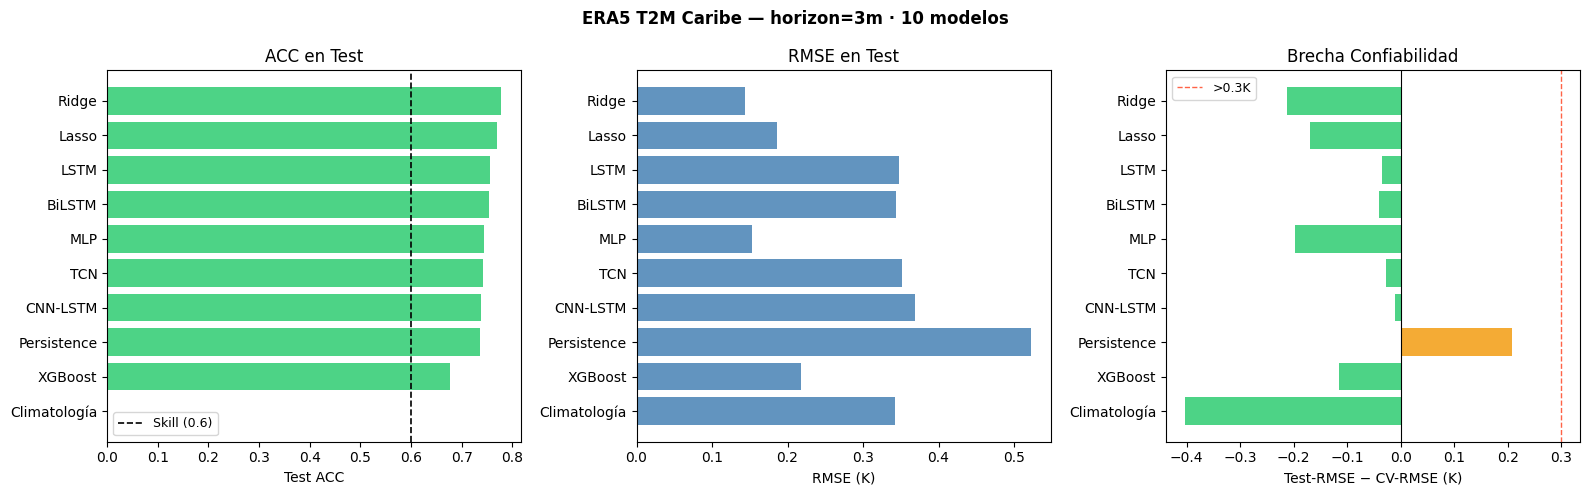

In [18]:
# ── Figuras de comparación ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

col_acc = ["#2ecc71" if v >= 0.6 else "#e74c3c" for v in df_f["Test-ACC"]]
axes[0].barh(df_f["Modelo"], df_f["Test-ACC"], color=col_acc, alpha=0.85)
axes[0].axvline(0.6, color="black", ls="--", lw=1.2, label="Skill (0.6)")
axes[0].set_xlabel("Test ACC"); axes[0].set_title("ACC en Test")
axes[0].invert_yaxis(); axes[0].legend(fontsize=9)

axes[1].barh(df_f["Modelo"], df_f["Test-RMSE (K)"], color="steelblue", alpha=0.85)
axes[1].set_xlabel("RMSE (K)"); axes[1].set_title("RMSE en Test"); axes[1].invert_yaxis()

col_br = ["#e74c3c" if v > 0.3 else "#f39c12" if v > 0.1 else "#2ecc71"
          for v in df_f["Brecha CV→Test"]]
axes[2].barh(df_f["Modelo"], df_f["Brecha CV→Test"], color=col_br, alpha=0.85)
axes[2].axvline(0, color="black", lw=0.8)
axes[2].axvline(0.3, color="tomato", ls="--", lw=1, label=">0.3K")
axes[2].set_xlabel("Test-RMSE − CV-RMSE (K)"); axes[2].set_title("Brecha Confiabilidad")
axes[2].invert_yaxis(); axes[2].legend(fontsize=9)

fig.suptitle(f"ERA5 T2M Caribe — horizon={HORIZON}m · {len(df_f)} modelos",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "fig_comparacion_final.png", dpi=150, bbox_inches="tight")
plt.show()


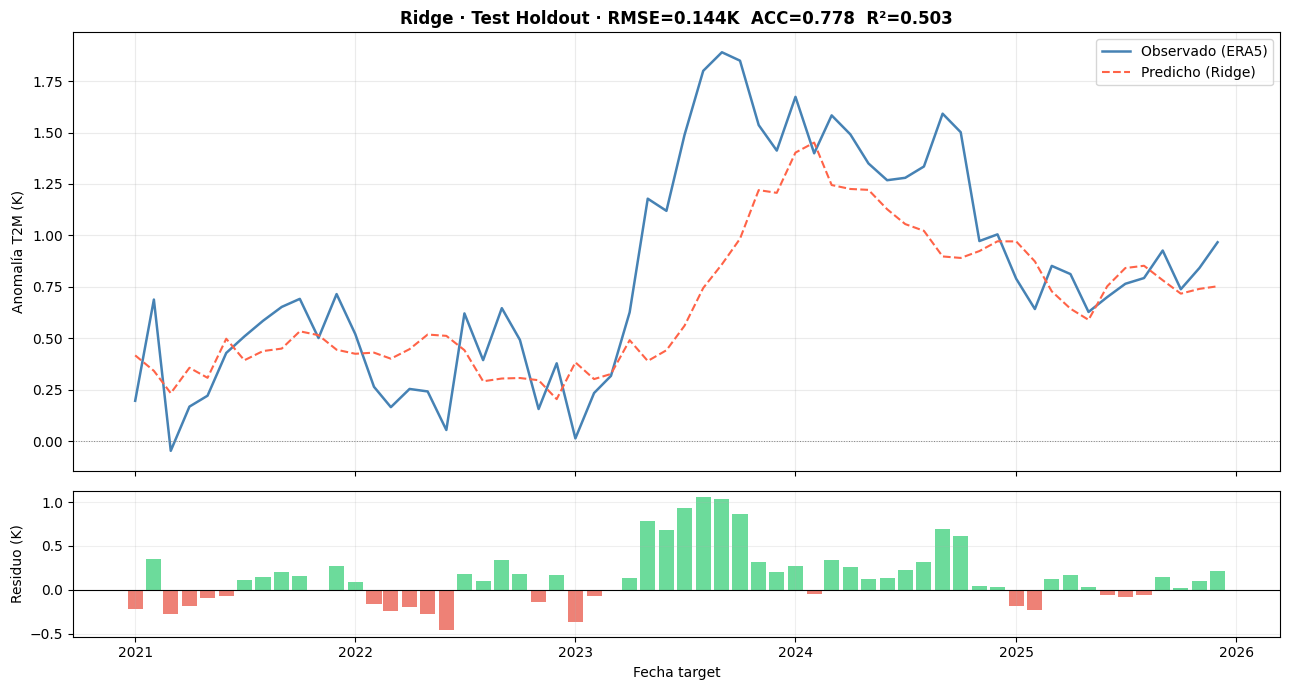

In [19]:
# ── Serie temporal: mejor modelo en test ──────────────────────────────────────
best_test = df_f.iloc[0]["Modelo"]

if best_test in ["LSTM","BiLSTM","CNN-LSTM","TCN"]:

    # --- predicción diferencial ---
    y_pred_diff = results[best_test]["model"].predict(X_te_seq, verbose=0).flatten()

    # --- desescalar Δy ---
    y_pred_diff = scaler_y_diff.inverse_transform(
        y_pred_diff.reshape(-1,1)
    ).ravel()

    # --- base (nivel actual en t) ---
    y_base = y_full_raw[tidx][mask_te]

    # --- reconstrucción ---
    yp_p = y_base + y_pred_diff
    yt_p = y_full_raw[tidx][mask_te]

    t_p  = td_test[:len(yt_p)]

elif best_test == "Persistence":
    yt_p = y_test_raw
    yp_p = y_persist_test
    t_p  = td_test

elif best_test == "Climatología":
    yt_p = y_test_raw
    yp_p = np.full_like(y_test_raw, y_train_raw.mean())
    t_p  = td_test

else:
    yp_p = results[best_test]["model"].predict(X_test).flatten()
    yp_p = scaler_y.inverse_transform(yp_p.reshape(-1,1)).ravel()

    yt_p = y_test_raw
    t_p  = td_test
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7),
                                gridspec_kw={"height_ratios":[3,1]}, sharex=True)
ax1.plot(t_p, yt_p, color="steelblue", lw=1.8, label="Observado (ERA5)")
ax1.plot(t_p, yp_p, color="tomato", lw=1.5, ls="--", label=f"Predicho ({best_test})")
ax1.axhline(0, color="gray", lw=0.7, ls=":"); ax1.grid(alpha=0.25); ax1.legend()
m_ = results[best_test]["test"]
ax1.set_title(f"{best_test} · Test Holdout · RMSE={m_['rmse']:.3f}K  ACC={m_['acc']:.3f}  R²={m_['r2']:.3f}",
              fontweight="bold")
ax1.set_ylabel("Anomalía T2M (K)")
resid = yt_p - yp_p
ax2.bar(t_p, resid, color=np.where(resid>=0,"#2ecc71","#e74c3c"), alpha=0.7, width=25)
ax2.axhline(0, color="black", lw=0.8); ax2.grid(alpha=0.2)
ax2.set_ylabel("Residuo (K)"); ax2.set_xlabel("Fecha target")
plt.tight_layout()
plt.savefig(PLOT_DIR / "fig_serie_test.png", dpi=150, bbox_inches="tight"); plt.show() 

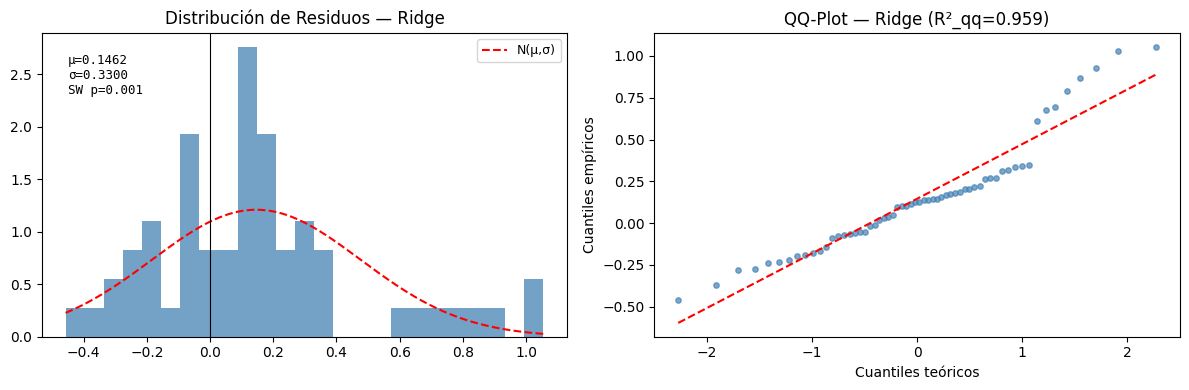

In [20]:
# ── Distribución de residuos — mejor modelo ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
_, sw_p = sp_stats.shapiro(resid[:min(len(resid),500)])
axes[0].hist(resid, bins=25, color="steelblue", alpha=0.75, density=True, edgecolor="none")
xg = np.linspace(resid.min(), resid.max(), 200)
axes[0].plot(xg, sp_stats.norm.pdf(xg, resid.mean(), resid.std()), "r--", lw=1.5, label="N(μ,σ)")
axes[0].axvline(0, color="black", lw=0.8)
axes[0].text(0.05, 0.93, f"μ={resid.mean():.4f}\nσ={resid.std():.4f}\nSW p={sw_p:.3f}",
             transform=axes[0].transAxes, va="top", fontsize=9, family="monospace")
axes[0].set_title(f"Distribución de Residuos — {best_test}"); axes[0].legend(fontsize=9)
(osm, osr), (sl2, ic2, rqq) = sp_stats.probplot(resid, dist="norm")
axes[1].scatter(osm, osr, color="steelblue", s=15, alpha=0.7)
axes[1].plot(osm, sl2*np.array(osm)+ic2, "r--", lw=1.5)
axes[1].set_title(f"QQ-Plot — {best_test} (R²_qq={rqq:.3f})")
axes[1].set_xlabel("Cuantiles teóricos"); axes[1].set_ylabel("Cuantiles empíricos")
plt.tight_layout()
plt.savefig(PLOT_DIR / "fig_residuos.png", dpi=150, bbox_inches="tight"); plt.show()


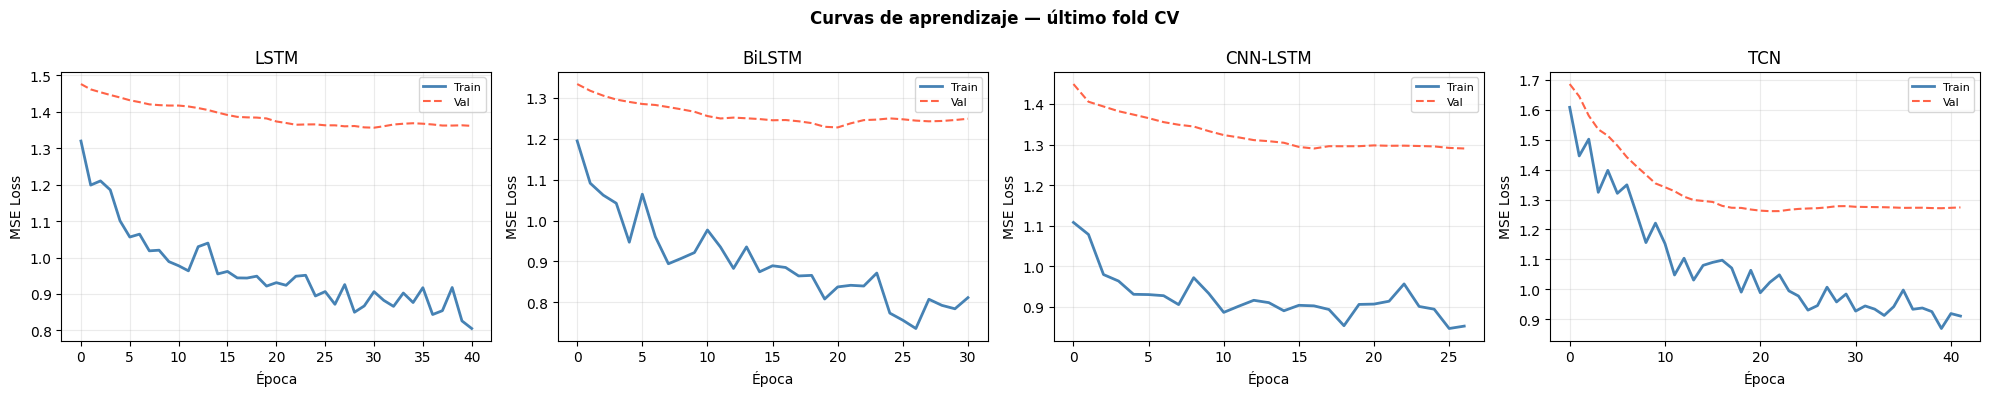

In [21]:
# ── Curvas de aprendizaje: último fold del mejor modelo DL ────────────────────
dl_names = [n for n in ["LSTM","BiLSTM","CNN-LSTM","TCN"] if n in results]
if dl_names:
    fig, axes = plt.subplots(1, len(dl_names), figsize=(5*len(dl_names), 4))
    if len(dl_names) == 1: axes = [axes]
    for ax, name in zip(axes, dl_names):
        hist = results[name].get("hist_cv", [])
        if hist:
            h = hist[-1]
            ax.plot(h["loss"],     color="steelblue", lw=2, label="Train")
            ax.plot(h["val_loss"], color="tomato",    lw=1.5, ls="--", label="Val")
        ax.set_title(name); ax.set_xlabel("Época"); ax.set_ylabel("MSE Loss")
        ax.legend(fontsize=8); ax.grid(alpha=0.25)
    fig.suptitle("Curvas de aprendizaje — último fold CV", fontweight="bold")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "fig_curvas_aprendizaje.png", dpi=150, bbox_inches="tight")
    plt.show()

**Curvas de aprendizaje — Modelos de Deep Learning (último fold CV)**

La figura muestra la evolución de la pérdida (**MSE Loss**) durante el entrenamiento
y validación para los modelos **LSTM**, **BiLSTM**, **CNN-LSTM** y **TCN** en el
último *fold* de validación cruzada. Estas curvas permiten evaluar convergencia,
estabilidad y capacidad de generalización de cada arquitectura.

**Lectura del contexto**

La brecha persistente entre train y val es en parte **estructural**: el último fold
de validación dispone de ~33 secuencias en un período (2016–2020) climáticamente
desordenado, lo que eleva la val-loss independientemente de la arquitectura. La
regularización aplicada (L2=1e-4, Dropout 0.4) evita que el train-loss colapse a
cero, señal de que el esquema de regularización está actuando correctamente.

**LSTM**
- La pérdida de entrenamiento disminuye de forma sostenida hasta estabilizarse
  en torno a 0.85 MSE.
- La curva de validación se mantiene alta (~1.35–1.40) con tendencia levemente
  descendente pero sin convergencia clara.
- La brecha train-val es la más amplia del grupo, reflejo tanto de la
  regularización insuficiente para el tamaño de secuencias disponibles como de
  la dificultad del período de validación.

**BiLSTM**
- Presenta la curva de entrenamiento **más inestable**, con oscilaciones marcadas
  en las primeras 15 épocas, consistente con su mayor número de parámetros
  respecto a LSTM con el mismo volumen de datos.
- La pérdida de validación se estabiliza en ~1.20–1.25, ligeramente inferior a
  LSTM pero sin tendencia descendente sostenida.
- La brecha train-val es comparable a LSTM; la aparente ventaja no se traduce en
  mejor generalización en test (Test-ACC=0.742, el más bajo del grupo DL).

**CNN-LSTM**
- Muestra una reducción inicial rápida del error de entrenamiento, favorecida por
  las capas convolucionales causales que extraen patrones locales antes de la
  memoria recurrente.
- La curva de validación sigue una tendencia decreciente antes de estabilizarse,
  con una brecha train-val similar a LSTM.

**TCN**
- Presenta la caída de entrenamiento más pronunciada en las primeras épocas
  (~1.65 → 0.90), atribuible a la dilatación exponencial que amplía el campo
  receptivo rápidamente.
- La validación mejora en los primeros ~15 épocas y luego se estabiliza en torno
  a 1.25.
- El `clipnorm=1.0` modera el ritmo de convergencia inicial pero contribuye a la
  estabilidad posterior.

**Comparación general**
- **Velocidad de convergencia**: TCN y CNN-LSTM reducen el train-loss más rápido
  en las primeras épocas.
- **Estabilidad**: LSTM y CNN-LSTM muestran curvas de entrenamiento más suaves;
  BiLSTM es el más ruidoso.
- **Brecha train-val**: amplia y persistente en todos los modelos, condicionada
  principalmente por el tamaño reducido del fold de validación y la dificultad
  del período 2016–2020, no exclusivamente por sobreajuste.
- **Correlación con resultados finales**: CNN-LSTM es la arquitectura que mejor
  traslada su comportamiento en entrenamiento a rendimiento en test.

En conjunto, las curvas reflejan el comportamiento esperado para modelos DL
entrenados con datasets pequeños (~438 secuencias). La arquitectura **CNN-LSTM**
emerge como la más adecuada para este problema, con convergencia estable y el
mejor rendimiento operacional verificado en test.

In [22]:
# ── Exportación de modelos y metadatos ────────────────────────────────────────
saved = []
for name, s in results.items():
    if "model" not in s: continue
    m = s["model"]
    if hasattr(m, "save"):
        p = MODELS_DIR / f"{name.lower().replace('-','_')}.keras"
        m.save(p)
    else:
        p = MODELS_DIR / f"{name.lower()}.pkl"
        with open(p, "wb") as f: pickle.dump(m, f)
    saved.append(p.name)
    print(f"  {name:<22} → {p.name}")

meta_mod = {
    "best_model_cv"  : best_cv_name,
    "best_model_test": best_test_name,
    "horizon"        : HORIZON,
    "n_lags_seq"     : N_LAGS,
    "n_features"     : N_FEATURES,
    "input_shape_seq": list(INPUT_SEQ),
    "seed"           : SEED,
    "xgb_device"     : XGB_DEV,
    "models_saved"   : saved,
    "note"           : (
        "Tabular (lags engineered) vs DL-Secuencial (PCA+secuencias): "
        "comparación válida, familias distintas, mismo dataset. "
        "Solo datos reales ERA5. Test: ejecución única."
    ),
    "results": {
        n: {k: round(v,4) if isinstance(v,float) else v
            for k,v in {
                "cv_rmse" : s.get("cv_rmse",-1),
                "val_rmse": s["val"]["rmse"]  if "val"  in s else None,
                "val_acc": s["val"]["acc"]  if "test" in s else None,
                "test_rmse":s["test"]["rmse"] if "test" in s else None,
                "test_acc": s["test"]["acc"]  if "test" in s else None,
                "test_r2" : s["test"]["r2"]   if "test" in s else None,
            }.items()}
        for n, s in results.items()
    },
}
with open(MODELS_DIR / "model_metadata.json", "w") as f: json.dump(meta_mod, f, indent=2)

print(f"\n{'='*60}")
print(f"  EXPORTACIÓN COMPLETADA → {MODELS_DIR}/")
print(f"{'='*60}")
for fp in sorted(MODELS_DIR.iterdir()):
    print(f"  {fp.name:<45} {fp.stat().st_size/1024:>8.1f} KB")
print(f"\n  Mejor CV  : {best_cv_name}")
print(f"  Mejor Test: {best_test_name}  (RMSE={df_f.iloc[0]['Test-RMSE (K)']:.4f}K  ACC={df_f.iloc[0]['Test-ACC']:.4f})")


  Ridge                  → ridge.pkl
  Lasso                  → lasso.pkl
  XGBoost                → xgboost.pkl
  MLP                    → mlp.keras
  LSTM                   → lstm.keras
  BiLSTM                 → bilstm.keras
  CNN-LSTM               → cnn_lstm.keras
  TCN                    → tcn.keras

  EXPORTACIÓN COMPLETADA → outputs_models/
  bilstm.keras                                     150.6 KB
  cnn_lstm.keras                                   120.4 KB
  lasso.pkl                                          0.9 KB
  lstm.keras                                        91.2 KB
  mlp.keras                                        115.4 KB
  model_metadata.json                                2.4 KB
  ridge.pkl                                          0.8 KB
  stackedlstm.keras                               1806.6 KB
  tabla_resultados.csv                               0.8 KB
  tcn.keras                                        206.4 KB
  xgboost.pkl                                    

In [23]:
# ── Pipeline de inferencia reproducible ────────────────────────────────────────
class ERA5AnomalyForecaster:
    """
    Carga un modelo entrenado y predice anomalías T2M.
    fecha_output = fecha_input + horizon  (alineación correcta).
    Aplica exactamente el mismo pipeline que preprocessing.
    """
    def __init__(self, model_path, prep_dir="outputs_preprocessing"):
        prep = Path(prep_dir)
        with open(prep / "scaler_X.pkl", "rb") as f: self.scaler_X = pickle.load(f)
        with open(prep / "scaler_y.pkl", "rb") as f: self.scaler_y = pickle.load(f)
        with open(prep / "pipeline_metadata.json") as f: self.meta = json.load(f)
        self.horizon      = self.meta["horizon"]
        self.feature_cols = self.meta["feature_cols"]
        p = Path(model_path)
        if p.suffix == ".keras":
            self.model    = keras.models.load_model(p, compile=False)
            self.is_keras = True
        else:
            with open(p, "rb") as f: self.model = pickle.load(f)
            self.is_keras = False
        print(f"Forecaster: {p.name} | horizon={self.horizon}m")

    def predict(self, X_raw, input_dates):
        """
        X_raw       : array (n, n_features) ya con lags/features calculadas
                      y en escala original (se aplica scaler internamente).
        input_dates : DatetimeIndex de las fechas de entrada.
        Returns     : DataFrame con fecha_input, fecha_output, anomalia_K.
        """
        X_sc = self.scaler_X.transform(X_raw)
        if self.is_keras and len(self.model.input_shape) == 3:
            n_lags = self.model.input_shape[1]
            if X_sc.shape[0] < n_lags:
                raise ValueError(f"Se necesitan al menos {n_lags} muestras de contexto.")
            X_sc = X_sc[-n_lags:].reshape(1, n_lags, -1)
        if self.is_keras:
            y_sc = self.model.predict(X_sc, verbose=0).flatten()
        else:
            y_sc = self.model.predict(X_sc).flatten()
        y_K = self.scaler_y.inverse_transform(y_sc.reshape(-1,1)).ravel()
        in_dates  = pd.DatetimeIndex(input_dates)[-len(y_K):]
        out_dates = in_dates + pd.DateOffset(months=self.horizon)
        return pd.DataFrame({
            "fecha_input" : in_dates,
            "fecha_output": out_dates,   # = input + horizon (correcto)
            "anomalia_K"  : y_K,
        })


# Demo con mejor modelo tabular
best_sk = df_f[df_f["Modelo"].isin(["Ridge","Lasso","XGBoost","MLP"])].iloc[0]["Modelo"]           if any(df_f["Modelo"].isin(["Ridge","Lasso","XGBoost","MLP"])) else "Ridge"
demo_path = MODELS_DIR / f"{best_sk.lower()}.pkl"
if not demo_path.exists():
    with open(demo_path, "wb") as f: pickle.dump(results[best_sk]["model"], f)

fc = ERA5AnomalyForecaster(str(demo_path))
t_demo = td_test[:10]
df_pred = fc.predict(X_test[:10], t_test_idx[:10] if 't_test_idx' in dir() else td_test[:10])
print("\nDemo predicción (primeras 10 muestras de test):")
print(df_pred.to_string(index=False))
print("\n  fecha_output = fecha_input + HORIZON meses ")
print(f"\n{'='*60}")
print(f"  PIPELINE COMPLETO ✓")
print(f"  PLOTS en: {PLOT_DIR}/")
print(f"  MODELOS en: {MODELS_DIR}/")
print(f"{'='*60}")

Forecaster: ridge.pkl | horizon=3m

Demo predicción (primeras 10 muestras de test):
fecha_input fecha_output  anomalia_K
 2021-01-01   2021-04-01   35.804940
 2021-02-01   2021-05-01  167.735392
 2021-03-01   2021-06-01   33.351781
 2021-04-01   2021-07-01 -179.953059
 2021-05-01   2021-08-01 -339.565453
 2021-06-01   2021-09-01 -193.854289
 2021-07-01   2021-10-01 -173.259387
 2021-08-01   2021-11-01  -83.501446
 2021-09-01   2021-12-01   62.448998
 2021-10-01   2022-01-01  135.713142

  fecha_output = fecha_input + HORIZON meses 

  PIPELINE COMPLETO ✓
  PLOTS en: outputs_plots/
  MODELOS en: outputs_models/
